# Import library

In [72]:
import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
seed = 0
np.random.seed(seed)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score


import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords


from sklearn.feature_extraction.text import TfidfVectorizer


import csv

import requests
from io import StringIO

import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Load the dataset

In [73]:
df = pd.DataFrame(Scrap_HOK)

df.to_csv('Hok_playstore.csv', index=False)


df = pd.DataFrame(Scrap_HOK)


jumlah_ulasan, jumlah_kolom = df.shape

In [74]:
df.shape

(169671, 11)

In [75]:
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,c3b67d9c-9b82-4d84-8e26-3fd1472e650a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Min, ini kenapa dah? aku cek Jaringan aman, di...",3,1,11.4.1.11,2026-08-16 21:54:28,Kami sangat memahami perasaan kalian. Jangan k...,2026-08-17 04:26:13,11.4.1.11
1,17fc21b8-8d1d-4520-a70c-7dea7005ceae,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"saya mengubah ulasan, karena entah kenapa akhi...",1,2,11.4.1.11,2026-08-11 12:28:33,"Halo kak,\nMaaf atas pengalaman kurang baik ya...",2026-08-12 03:06:26,11.4.1.11
2,0fed06e3-c350-416a-b92e-6e775e9a468e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,gamenya terlalu seimbang buat game lebih sulit...,1,1,11.4.1.11,2026-08-16 15:42:21,Kami sangat memahami perasaan Anda. Kemampuan ...,2026-08-17 03:28:13,11.4.1.11
3,0ffc4b6e-2749-46e0-aaa6-07d96d73251c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Game Nya Sangat Bagus, Event Nya Banyak dan se...",5,1,11.4.1.11,2026-08-09 14:54:08,None,NaT,11.4.1.11
4,f17e7c0e-37cc-43b9-abe1-f946b019ef36,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"gamenya bagusss bangett, aku suka grafiknya da...",5,1,11.4.1.11,2026-08-14 06:09:40,None,NaT,11.4.1.11
...,...,...,...,...,...,...,...,...,...,...,...
169666,d9406564-4973-40b5-85df-85b259e0ed70,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,😠😠😠😠😠😠😠,2,0,None,2024-07-24 09:49:31,"Hi player, \nWe sincerely apologize for any di...",2024-07-25 02:16:40,None
169667,4a94909f-29c3-405b-a2cc-a9a7e245550a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,👍,2,0,None,2024-11-03 01:11:50,"Hi player, \nThank you for your love and atten...",2024-11-03 04:43:04,None
169668,1c9e3a08-8887-496a-b9b2-5d10edd16fd7,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,🎼,2,0,None,2024-08-02 10:23:20,"Hi player, \nThanks for your message, but we a...",2024-08-04 04:19:41,None
169669,e0dc87ff-f8bb-4bc6-bc0c-4f44f301e51c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,🐒,2,0,None,2024-10-01 16:23:15,None,NaT,None


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169671 entries, 0 to 169670
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              169671 non-null  object        
 1   userName              169671 non-null  object        
 2   userImage             169671 non-null  object        
 3   content               169670 non-null  object        
 4   score                 169671 non-null  int64         
 5   thumbsUpCount         169671 non-null  int64         
 6   reviewCreatedVersion  119743 non-null  object        
 7   at                    169671 non-null  datetime64[ns]
 8   replyContent          33287 non-null   object        
 9   repliedAt             33287 non-null   datetime64[ns]
 10  appVersion            119743 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 14.2+ MB


In [77]:
df.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,1
score,0
thumbsUpCount,0
reviewCreatedVersion,49928
at,0
replyContent,136384
repliedAt,136384


In [78]:
def handle_null_content(dataframe):

    if dataframe['content'].isnull().any():
        null_count = dataframe['content'].isnull().sum()
        print(f"Ditemukan {null_count} nilai null. Menghapus baris terkait...")
        dataframe = dataframe.dropna(subset=['content']).reset_index(drop=True)
    else:
        print("Tidak ada nilai null pada kolom 'content'.")

    return dataframe


df = handle_null_content(df)

Ditemukan 1 nilai null. Menghapus baris terkait...


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169670 entries, 0 to 169669
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              169670 non-null  object        
 1   userName              169670 non-null  object        
 2   userImage             169670 non-null  object        
 3   content               169670 non-null  object        
 4   score                 169670 non-null  int64         
 5   thumbsUpCount         169670 non-null  int64         
 6   reviewCreatedVersion  119742 non-null  object        
 7   at                    169670 non-null  datetime64[ns]
 8   replyContent          33287 non-null   object        
 9   repliedAt             33287 non-null   datetime64[ns]
 10  appVersion            119742 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 14.2+ MB


In [80]:
df.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,49928
at,0
replyContent,136383
repliedAt,136383


# All preprocessing function

In [81]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'RT[\s]', '', text)
    text = re.sub(r"http\S+", '', text)
    text = re.sub(r'[0-9]+', '', text)
    text = re.sub(r'[^\w\s]', '', text)

    text = text.replace('\n', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip(' ')
    return text

In [82]:
def casefoldingText(text):
    text = text.lower()
    return text

In [83]:
def tokenizingText(text):
    text = word_tokenize(text)
    return text

In [84]:
def filteringText(text):
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

In [85]:
def stemmingText(text):

    factory = StemmerFactory()
    stemmer = factory.create_stemmer()


    words = text.split()


    stemmed_words = [stemmer.stem(word) for word in words]


    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

In [86]:
def toSentence(list_words):
    sentence = ' '.join(word for word in list_words)
    return sentence

In [87]:
slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal"}
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [88]:
#Applied all the function the current dataframe

df['text_clean'] = df['content'].apply(cleaningText)


df['text_casefoldingText'] = df['text_clean'].apply(casefoldingText)


df['text_slangwords'] = df['text_casefoldingText'].apply(fix_slangwords)


df['text_tokenizingText'] = df['text_slangwords'].apply(tokenizingText)


df['text_stopword'] = df['text_tokenizingText'].apply(filteringText)


df['text_akhir'] = df['text_stopword'].apply(toSentence)

# Labeling

In [89]:
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')

if response.status_code == 200:

    reader = csv.reader(StringIO(response.text), delimiter=',')

    for row in reader:

        lexicon_positive[row[0]] = int(row[1])

else:
    print("Failed to fetch positive lexicon data")


lexicon_negative = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')


if response.status_code == 200:

    reader = csv.reader(StringIO(response.text), delimiter=',')


    for row in reader:

        lexicon_negative[row[0]] = int(row[1])

else:
    print("Failed to fetch negative lexicon data")

In [90]:

def sentiment_analysis_lexicon_indonesia(text):

    score = 0


    for word in text:


        if (word in lexicon_positive):
            score = score + lexicon_positive[word]


    for word in text:


        if (word in lexicon_negative):
            score = score + lexicon_negative[word]


    polarity=''


    if (score >= 0):
        polarity = 'positive'

    elif (score < 0):
        polarity = 'negative'



    return score, polarity


In [91]:
results = df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
df['polarity_score'] = results[0]
df['polarity'] = results[1]
print(df['polarity'].value_counts())

polarity
positive    107176
negative     62494
Name: count, dtype: int64


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169670 entries, 0 to 169669
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              169670 non-null  object        
 1   userName              169670 non-null  object        
 2   userImage             169670 non-null  object        
 3   content               169670 non-null  object        
 4   score                 169670 non-null  int64         
 5   thumbsUpCount         169670 non-null  int64         
 6   reviewCreatedVersion  119742 non-null  object        
 7   at                    169670 non-null  datetime64[ns]
 8   replyContent          33287 non-null   object        
 9   repliedAt             33287 non-null   datetime64[ns]
 10  appVersion            119742 non-null  object        
 11  text_clean            169670 non-null  object        
 12  text_casefoldingText  169670 non-null  object        
 13 

# Feature Extraction

In [93]:
X = df['text_akhir']
y = df['polarity']

In [94]:
tfidf = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8 )
X_tfidf = tfidf.fit_transform(X)

In [95]:
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

In [96]:
features_df

,adil,aja,akun,ama,aneh,aov,asik,bagus,baguss,bang,...,tpi,trus,tuh,turun,udah,udh,update,war,wifi,yg
0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.195173,0.0,0.0,0.000000,0.0,0.000000
1,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.307468,0.0,0.0,0.000000,0.0,0.000000
2,0.0,0.144071,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.224813,0.0,0.000000
3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.076364,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.242413
4,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169665,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000
169666,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000
169667,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000
169668,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000


# Train Test Split data

In [97]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Modeling

Naive Bayes

In [98]:
from sklearn.naive_bayes import BernoulliNB


naive_bayes = BernoulliNB()


naive_bayes.fit(X_train.toarray(), y_train)


y_pred_train_nb = naive_bayes.predict(X_train.toarray())
y_pred_test_nb = naive_bayes.predict(X_test.toarray())


accuracy_train_nb = accuracy_score(y_pred_train_nb, y_train)
accuracy_test_nb = accuracy_score(y_pred_test_nb, y_test)

print('Naive Bayes - accuracy_train:', accuracy_train_nb)
print('Naive Bayes - accuracy_test:', accuracy_test_nb)

Naive Bayes - accuracy_train: 0.7568441680910002
Naive Bayes - accuracy_test: 0.7574114457476278


Random Forest

In [99]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier()


random_forest.fit(X_train.toarray(), y_train)


y_pred_train_rf = random_forest.predict(X_train.toarray())
y_pred_test_rf = random_forest.predict(X_test.toarray())


accuracy_train_rf = accuracy_score(y_pred_train_rf, y_train)
accuracy_test_rf = accuracy_score(y_pred_test_rf, y_test)


print('Random Forest - accuracy_train:', accuracy_train_rf)
print('Random Forest - accuracy_test:', accuracy_test_rf)

Random Forest - accuracy_train: 0.9565701066776684
Random Forest - accuracy_test: 0.8807980196852714


Logistic Regression

In [100]:
from sklearn.linear_model import LogisticRegression


logistic_regression = LogisticRegression()


logistic_regression.fit(X_train.toarray(), y_train)


y_pred_train_lr = logistic_regression.predict(X_train.toarray())
y_pred_test_lr = logistic_regression.predict(X_test.toarray())


accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)


accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)

print('Logistic Regression - accuracy_train:', accuracy_train_lr)
print('Logistic Regression - accuracy_test:', accuracy_test_lr)

Logistic Regression - accuracy_train: 0.8898155242529616
Logistic Regression - accuracy_test: 0.8899923380680144


Decision Tree

In [101]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier()


decision_tree.fit(X_train.toarray(), y_train)

y_pred_train_dt = decision_tree.predict(X_train.toarray())
y_pred_test_dt = decision_tree.predict(X_test.toarray())

accuracy_train_dt = accuracy_score(y_pred_train_dt, y_train)
accuracy_test_dt = accuracy_score(y_pred_test_dt, y_test)

print('Decision Tree - accuracy_train:', accuracy_train_dt)
print('Decision Tree - accuracy_test:', accuracy_test_dt)

Decision Tree - accuracy_train: 0.9565701066776684
Decision Tree - accuracy_test: 0.8533918783520953


Feature Extraction for Deep Learning Model

In [102]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout

In [103]:
y

,polarity
0,negative
1,positive
2,positive
3,positive
4,positive
...,...
169665,positive
169666,positive
169667,positive
169668,positive


In [104]:
print(type(y))

<class 'pandas.core.series.Series'>


In [105]:
y_train_num = y_train.map({'negative': 0, 'positive': 1}).values
y_test_num = y_test.map({'negative': 0, 'positive': 1}).values

In [106]:
X_train_rnn = X_train.toarray().reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_rnn = X_test.toarray().reshape((X_test.shape[0], 1, X_test.shape[1]))

In [107]:
input_shape = (X_train_rnn.shape[1], X_train_rnn.shape[2])

RNN

In [108]:
rnn_model = Sequential([
    SimpleRNN(64, input_shape=input_shape),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [109]:
rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
rnn_model.fit(X_train_rnn, y_train_num, epochs=5, batch_size=64, validation_split=0.1, verbose=1)

y_pred_train_rnn = (rnn_model.predict(X_train_rnn) > 0.5).astype(int)
y_pred_test_rnn = (rnn_model.predict(X_test_rnn) > 0.5).astype(int)

accuracy_train_rnn = accuracy_score(y_train_num, y_pred_train_rnn)
accuracy_test_rnn = accuracy_score(y_test_num, y_pred_test_rnn)

print(f"RNN - accuracy_train: {accuracy_train_rnn}")
print(f"RNN - accuracy_test: {accuracy_test_rnn}\n")

Epoch 1/5
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8749 - loss: 0.3186 - val_accuracy: 0.8901 - val_loss: 0.2853
Epoch 2/5
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8899 - loss: 0.2893 - val_accuracy: 0.8911 - val_loss: 0.2819
Epoch 3/5
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8907 - loss: 0.2865 - val_accuracy: 0.8897 - val_loss: 0.2812
Epoch 4/5
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8915 - loss: 0.2850 - val_accuracy: 0.8904 - val_loss: 0.2793
Epoch 5/5
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8924 - loss: 0.2832 - val_accuracy: 0.8907 - val_loss: 0.2802
4242/4242 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
RNN - accuracy_train: 0.8937348971532976
RNN - accuracy_test: 0.8924382625095774



GRU

In [110]:
GRU_model = Sequential([
    GRU(64, input_shape=input_shape),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [111]:
GRU_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
GRU_model.fit(X_train_rnn, y_train_num, epochs=5, batch_size=64, validation_split=0.1, verbose=1)

y_pred_train_gru = (GRU_model.predict(X_train_rnn) > 0.5).astype(int)
y_pred_test_gru = (GRU_model.predict(X_test_rnn) > 0.5).astype(int)

accuracy_train_gru = accuracy_score(y_train_num, y_pred_train_gru)
accuracy_test_gru = accuracy_score(y_test_num, y_pred_test_gru)

print(f"GRU - accuracy_train: {accuracy_train_gru}")
print(f"GRU - accuracy_test: {accuracy_test_gru}")

Epoch 1/5
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8740 - loss: 0.3197 - val_accuracy: 0.8896 - val_loss: 0.2859
Epoch 2/5
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8904 - loss: 0.2887 - val_accuracy: 0.8895 - val_loss: 0.2825
Epoch 3/5
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8918 - loss: 0.2855 - val_accuracy: 0.8908 - val_loss: 0.2808
Epoch 4/5
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8917 - loss: 0.2839 - val_accuracy: 0.8912 - val_loss: 0.2789
Epoch 5/5
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8922 - loss: 0.2821 - val_accuracy: 0.8935 - val_loss: 0.2779
4242/4242 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
GRU - accuracy_train: 0.894530559321035
GRU - accuracy_test: 0.8945600282902104


LSTM

In [112]:
LSTM_model = Sequential([
    LSTM(64, input_shape=input_shape),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [113]:
LSTM_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
LSTM_model.fit(X_train_rnn, y_train_num, epochs=5, batch_size=64, validation_split=0.1, verbose=1)

y_pred_train_lstm = (LSTM_model.predict(X_train_rnn) > 0.5).astype(int)
y_pred_test_lstm = (LSTM_model.predict(X_test_rnn) > 0.5).astype(int)

accuracy_train_lstm = accuracy_score(y_train_num, y_pred_train_lstm)
accuracy_test_lstm = accuracy_score(y_test_num, y_pred_test_lstm)

print(f"LSTM - accuracy_train: {accuracy_train_lstm}")
print(f"LSTM - accuracy_test: {accuracy_test_lstm}\n")

Epoch 1/5
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8752 - loss: 0.3195 - val_accuracy: 0.8907 - val_loss: 0.2838
Epoch 2/5
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8907 - loss: 0.2871 - val_accuracy: 0.8897 - val_loss: 0.2812
Epoch 3/5
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8913 - loss: 0.2835 - val_accuracy: 0.8921 - val_loss: 0.2782
Epoch 4/5
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8925 - loss: 0.2817 - val_accuracy: 0.8916 - val_loss: 0.2775
Epoch 5/5
1909/1909 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8931 - loss: 0.2802 - val_accuracy: 0.8929 - val_loss: 0.2765
4242/4242 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
LSTM - accuracy_train: 0.8951936111274827
LSTM - accuracy_test: 0.8931749867389639



# Visualization and benchmark for each Models

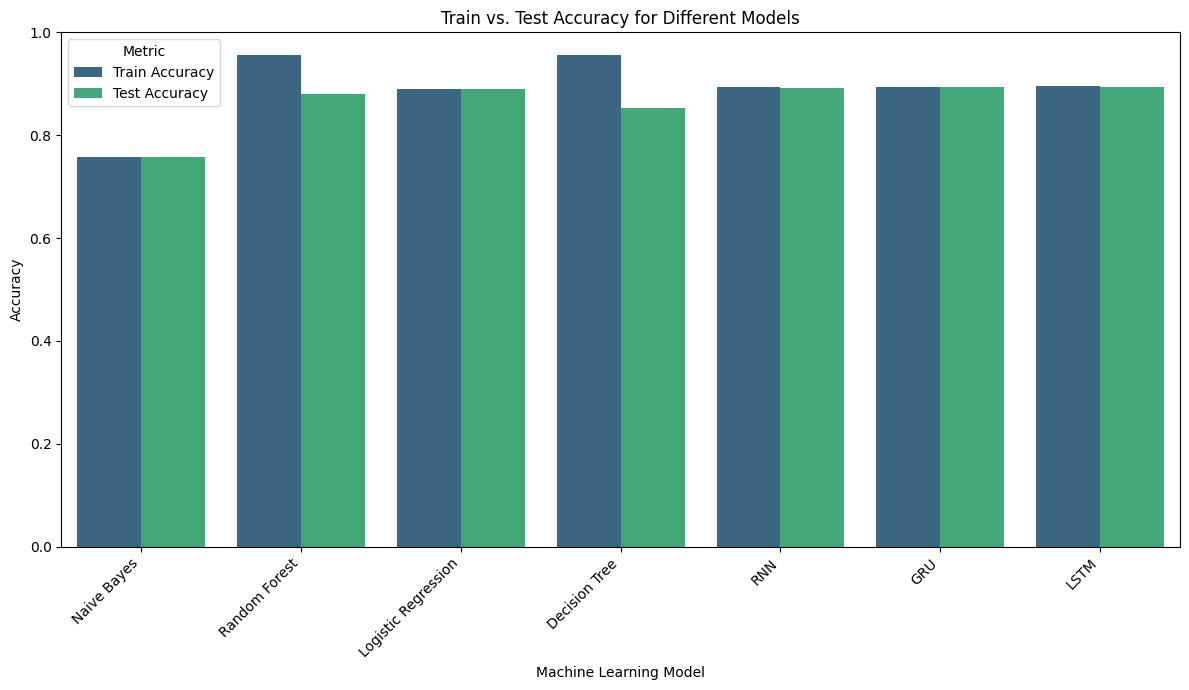

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

accuracy_data = {
    'Model': ['Naive Bayes', 'Random Forest', 'Logistic Regression', 'Decision Tree','RNN','GRU','LSTM'],
    'Train Accuracy': [accuracy_train_nb, accuracy_train_rf, accuracy_train_lr, accuracy_train_dt,accuracy_train_rnn,accuracy_train_gru,accuracy_train_lstm],
    'Test Accuracy': [accuracy_test_nb, accuracy_test_rf, accuracy_test_lr, accuracy_test_dt,accuracy_test_rnn,accuracy_test_gru,accuracy_test_lstm]
}
accuracy_df = pd.DataFrame(accuracy_data)


accuracy_melted = accuracy_df.melt(id_vars='Model', var_name='Metric', value_name='Accuracy')

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Accuracy', hue='Metric', data=accuracy_melted, palette='viridis')
plt.title('Train vs. Test Accuracy for Different Models')
plt.ylabel('Accuracy')
plt.xlabel('Machine Learning Model')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [115]:
accuracy_data = {
    'Model': [
        'Naive Bayes',
        'Random Forest',
        'Logistic Regression',
        'Decision Tree',
        'RNN',
        'GRU',
        'LSTM'
    ],
    'Train Accuracy': [
        accuracy_train_nb,
        accuracy_train_rf,
        accuracy_train_lr,
        accuracy_train_dt,
        accuracy_train_rnn,
        accuracy_train_gru,
        accuracy_train_lstm
    ],
    'Test Accuracy': [
        accuracy_test_nb,
        accuracy_test_rf,
        accuracy_test_lr,
        accuracy_test_dt,
        accuracy_test_rnn,
        accuracy_test_gru,
        accuracy_test_lstm
    ]
}

In [116]:
df_benchmark = pd.DataFrame(accuracy_data)

In [117]:

df_sorted_test = df_benchmark.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)


df_sorted_train = df_benchmark.sort_values(by='Train Accuracy', ascending=False).reset_index(drop=True)


df_display = df_sorted_test.copy()
df_display['Train Accuracy (%)'] = (df_display['Train Accuracy'] * 100).map('{:.2f}%'.format)
df_display['Test Accuracy (%)'] = (df_display['Test Accuracy'] * 100).map('{:.2f}%'.format)

print("=== Ranking Train and Test Accuracy ===")
print(df_display[['Model', 'Train Accuracy (%)', 'Test Accuracy (%)']])

print("\n" + "="*50)
print(f"Top 1 Test Accuracy  : {df_sorted_test.iloc[0]['Model']} ({df_sorted_test.iloc[0]['Test Accuracy']*100:.2f}%)")
print(f"Top 1 Train Accuracy : {df_sorted_train.iloc[0]['Model']} ({df_sorted_train.iloc[0]['Train Accuracy']*100:.2f}%)")
print("="*50)

=== Ranking Train and Test Accuracy ===
                 Model Train Accuracy (%) Test Accuracy (%)
0                  GRU             89.45%            89.46%
1                 LSTM             89.52%            89.32%
2                  RNN             89.37%            89.24%
3  Logistic Regression             88.98%            89.00%
4        Random Forest             95.66%            88.08%
5        Decision Tree             95.66%            85.34%
6          Naive Bayes             75.68%            75.74%

Top 1 Test Accuracy  : GRU (89.46%)
Top 1 Train Accuracy : Random Forest (95.66%)


Summary: Random Forest as a tree based model has a highest training accuracy (95.66%), GRU as a deep learning model has a highest test accuracy (89.46%)